# Fan failure prediction: deterministic synthetic evidence

## Purpose and scope

This notebook reproduces and audits the repository's fan-risk workflow. It uses the existing deterministic generator, NumPy trainer, and runtime model rather than reimplementing them.

**Synthetic-data limitation.** Every row and label below is simulated. A positive label means `failure_within_7d` under the generator's assumed probability law; it is not an observed equipment failure, a validated maintenance forecast, or evidence about any facility. Results demonstrate software behavior on one synthetic distribution only.

In [1]:
from pathlib import Path
import csv
import hashlib
import io
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

# Resolve the repository using only relative locations, whether Jupyter starts the
# kernel in the repository root or beside this notebook.
execution_dir = Path.cwd()
REPO_ROOT = next(
    (candidate for candidate in (execution_dir, execution_dir.parent) if
     (candidate / "simulator").is_dir() and (candidate / "pyproject.toml").is_file()),
    None,
)
if REPO_ROOT is None:
    raise RuntimeError("Start Jupyter from the repository root or notebooks directory.")

# Repository-relative imports and artifact paths; no personal path is embedded.
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from simulator.fan_health import FEATURE_NAMES, LogisticRiskModel
from simulator.generate_fan_data import DEFAULT_ROWS, DEFAULT_SEED, generate_rows
from simulator.train_fan_model import _matrix, _metrics, _sigmoid, fit_model

DATASET_PATH = REPO_ROOT / "simulator/data/fan_failure_synthetic.csv"
ARTIFACT_PATH = REPO_ROOT / "simulator/models/fan_risk_logistic.json"
METRICS_PATH = REPO_ROOT / "simulator/models/fan_risk_logistic.metrics.json"
SEED, ROWS, ITERATIONS = DEFAULT_SEED, DEFAULT_ROWS, 2400
TEST_FRACTION, CLASSIFICATION_THRESHOLD = 0.20, 0.50
plt.style.use("seaborn-v0_8-whitegrid")
BLUE, ORANGE, GRAY = "#0072B2", "#D55E00", "#6B7280"

print(f"Repository located relative to kernel directory: {REPO_ROOT.name}")
print(f"Generator seed={SEED:,}; rows={ROWS:,}; trainer iterations={ITERATIONS:,}")

Repository located relative to kernel directory: Simulation_Room
Generator seed=20,260,805; rows=2,400; trainer iterations=2,400


## 1. Generate the deterministic synthetic data

The generator samples filter clog, fan speed, and run hours; derives correlated wear, vibration, and bearing temperature; computes a hidden logistic failure probability; and samples a binary label. Reusing the same seed yields the same rounded rows and labels.

In [2]:
rows = generate_rows(rows=ROWS, seed=SEED)
df = pd.DataFrame(rows)
repeated_rows = generate_rows(rows=ROWS, seed=SEED)
assert rows == repeated_rows, "Generator is not deterministic for the declared seed."
assert tuple(df.columns[:-1]) == FEATURE_NAMES
assert len(df) == ROWS

# Validate the checked-in CSV as both typed records and exact bytes. The generator
# rounds predictors before storage; labels were sampled from the unrounded values.
with DATASET_PATH.open(newline="", encoding="utf-8") as dataset_file:
    stored_rows = []
    for record in csv.DictReader(dataset_file):
        stored_rows.append({
            **{name: float(record[name]) for name in FEATURE_NAMES},
            "failure_within_7d": int(record["failure_within_7d"]),
        })
fieldnames = [*FEATURE_NAMES, "failure_within_7d"]
generated_csv = io.StringIO(newline="")
writer = csv.DictWriter(generated_csv, fieldnames=fieldnames)
writer.writeheader()
writer.writerows(rows)
generated_bytes = generated_csv.getvalue().encode("utf-8")
stored_bytes = DATASET_PATH.read_bytes()
assert stored_rows == rows, "Checked-in CSV records differ from deterministic generation."
assert stored_bytes == generated_bytes, "Checked-in CSV bytes differ from generator output."

print(f"Generated {len(df):,} rows; repeated generation and checked-in CSV are exactly equal.")
print(f"Checked-in CSV SHA-256: {hashlib.sha256(stored_bytes).hexdigest()}")
display(df.head())

Generated 2,400 rows; repeated generation and checked-in CSV are exactly equal.
Checked-in CSV SHA-256: 8cd9248067f299eab96c61fdfa500170ecbfa794518d932886201626a6aa06ee


,filter_clog_pct,fan_speed_pct,vibration_mm_s,bearing_temp_c,run_hours,failure_within_7d
0,0.487753,0.913505,2.194470,61.711004,1179.844188,1
1,0.811176,0.724681,3.287590,63.223616,5197.735823,1
2,0.025172,0.893742,1.492565,51.851760,3015.195051,0
3,0.637881,0.868735,3.756364,65.382704,7291.805479,1
4,0.357116,0.544001,2.603343,51.532311,3992.871296,1


## 2. Distributions

The table reports the synthetic sample's range, quartiles, mean, and standard deviation. The plots show feature marginals by sampled label. Overlap is expected because the label is probabilistically sampled rather than assigned by a hard rule. Colors are paired with labels, so identity does not rely on color alone.

In [3]:
summary = df.describe().T[["min", "25%", "50%", "mean", "75%", "max", "std"]]
summary["missing"] = df.isna().sum()
summary["unique"] = df.nunique()
display(summary.round(3))
label_counts = df["failure_within_7d"].value_counts().sort_index().rename(index={0: "no synthetic failure", 1: "synthetic failure"})
print("Label distribution:")
display(pd.DataFrame({"rows": label_counts, "share": (label_counts / len(df)).round(4)}))

,min,25%,50%,mean,75%,max,std,missing,unique
filter_clog_pct,0.000,0.242,0.480,0.482,0.725,0.949,0.277,0,2397
fan_speed_pct,0.080,0.311,0.551,0.547,0.778,1.000,0.269,0,2399
vibration_mm_s,0.404,1.781,2.363,2.398,3.030,4.665,0.799,0,2399
bearing_temp_c,33.130,48.701,54.625,54.413,60.090,74.723,7.912,0,2400
run_hours,0.923,2097.118,4302.806,4413.884,6727.181,8997.663,2625.977,0,2400
failure_within_7d,0.000,0.000,0.000,0.298,1.000,1.000,0.457,0,2


Label distribution:


,rows,share
failure_within_7d,,
no synthetic failure,1685,0.7021
synthetic failure,715,0.2979


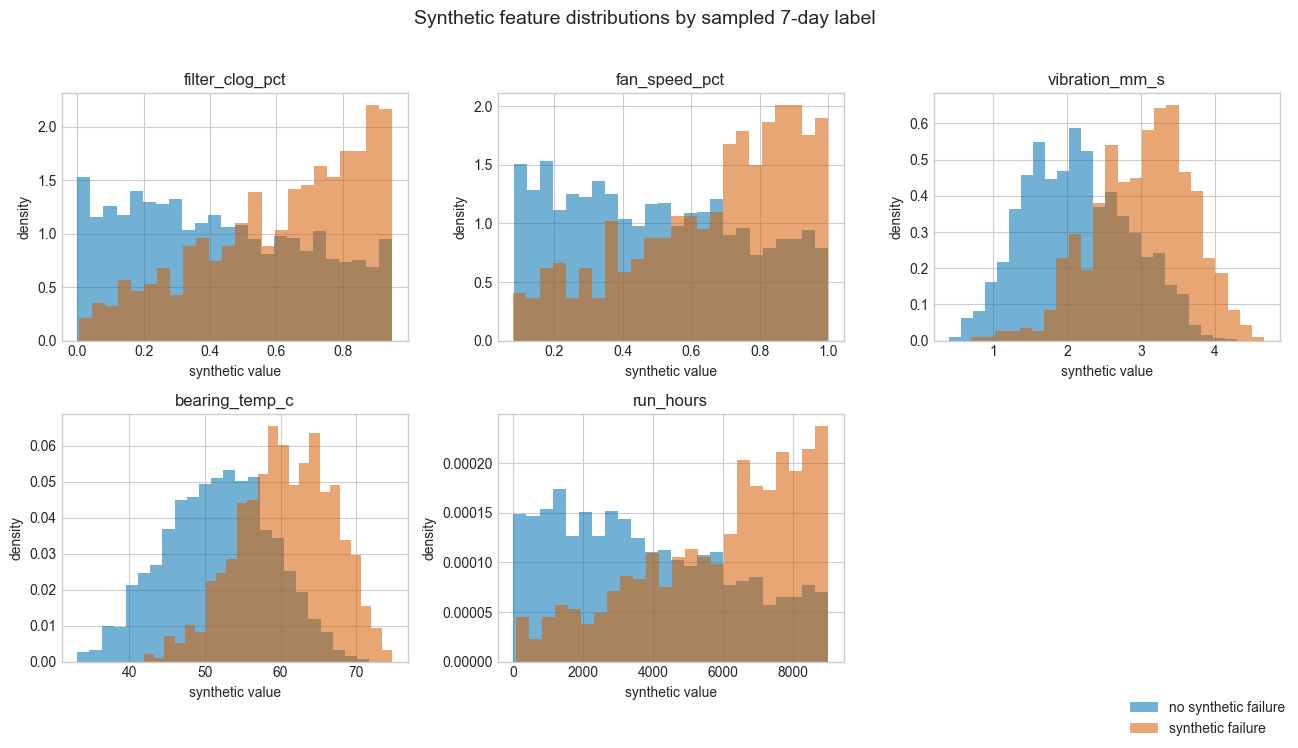

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(13, 7.5))
for ax, feature in zip(axes.flat, FEATURE_NAMES):
    for label, color, name in [(0, BLUE, "no synthetic failure"), (1, ORANGE, "synthetic failure")]:
        ax.hist(df.loc[df["failure_within_7d"] == label, feature], bins=24, density=True,
                alpha=0.55, color=color, label=name)
    ax.set_title(feature)
    ax.set_ylabel("density")
    ax.set_xlabel("synthetic value")
axes.flat[-1].axis("off")
handles, legend_labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, legend_labels, loc="lower right", frameon=False)
fig.suptitle("Synthetic feature distributions by sampled 7-day label", fontsize=14)
fig.tight_layout(rect=(0, 0.04, 1, 0.96))
plt.show()

## 3. Deterministic train/holdout process

The existing trainer applies `numpy.random.default_rng(seed).permutation`, takes the first 80% as training data and the remainder as a holdout, standardizes using **training-only** means and scales, initializes all logistic coefficients to zero, and performs 2,400 full-batch gradient-descent iterations at learning rate 0.08. No holdout row is used to fit standardization or coefficients.

The following reconstruction is for evaluation visibility. The authoritative model fit remains the imported `fit_model` function, checked exactly later.

In [5]:
features, labels = _matrix(rows)
rng = np.random.default_rng(SEED)
indices = rng.permutation(len(rows))
split = max(1, int(len(rows) * (1.0 - TEST_FRACTION)))
train_idx, holdout_idx = indices[:split], indices[split:]
train_x, holdout_x = features[train_idx], features[holdout_idx]
train_y, holdout_y = labels[train_idx], labels[holdout_idx]
means = train_x.mean(axis=0)
scales = train_x.std(axis=0)
scales[scales < 1e-9] = 1.0
standardized_train = (train_x - means) / scales
weights = np.zeros(standardized_train.shape[1], dtype=float)
intercept = 0.0
for _ in range(ITERATIONS):
    train_probabilities = _sigmoid(standardized_train @ weights + intercept)
    error = train_probabilities - train_y
    weights -= 0.08 * (standardized_train.T @ error / len(train_y))
    intercept -= 0.08 * float(error.mean())
holdout_probabilities = _sigmoid(((holdout_x - means) / scales) @ weights + intercept)
assert len(set(train_idx).intersection(set(holdout_idx))) == 0
assert len(train_idx) + len(holdout_idx) == ROWS
print(f"Train rows: {len(train_idx):,} | Holdout rows: {len(holdout_idx):,} | Overlap: 0")
print(f"Train positive prevalence: {train_y.mean():.4f}")
print(f"Holdout positive prevalence: {holdout_y.mean():.4f}")

Train rows: 1,920 | Holdout rows: 480 | Overlap: 0
Train positive prevalence: 0.2917
Holdout positive prevalence: 0.3229


## 4. Baseline comparison and expanded metrics

A prevalence-aware baseline predicts the training-set majority class for every holdout row. Accuracy alone can make that baseline look deceptively useful, so the comparison includes balanced accuracy, precision, recall, specificity, F1, ROC AUC, Brier score, and log loss. For Brier score and log loss, lower is better; for the other metrics, higher is better.

In [6]:
def metric_row(name, probabilities, truth_values):
    values = _metrics(np.asarray(probabilities, dtype=float), np.asarray(truth_values, dtype=float))
    return {"model": name, **values}

train_prevalence = float(train_y.mean())
majority_probability = 1.0 if train_prevalence >= 0.5 else 0.0
baseline_probabilities = np.full_like(holdout_y, majority_probability, dtype=float)
comparison = pd.DataFrame([
    metric_row("majority-class baseline", baseline_probabilities, holdout_y),
    metric_row("logistic model", holdout_probabilities, holdout_y),
]).set_index("model")
metric_columns = ["accuracy", "balanced_accuracy", "precision", "recall", "specificity",
                  "f1_score", "roc_auc", "brier_score", "log_loss"]
display(comparison[metric_columns])
print("The model improves balanced accuracy and ranking/probability metrics over the majority-class baseline;")
print("the baseline has zero positive recall and no practical ability to identify synthetic failures.")

,accuracy,balanced_accuracy,precision,recall,specificity,f1_score,roc_auc,brier_score,log_loss
model,,,,,,,,,
majority-class baseline,0.6771,0.5000,0.000,0.0000,1.0000,0.0000,0.5000,0.3229,8.9225
logistic model,0.8042,0.7491,0.748,0.5935,0.9046,0.6619,0.8449,0.1467,0.4471


The model improves balanced accuracy and ranking/probability metrics over the majority-class baseline;
the baseline has zero positive recall and no practical ability to identify synthetic failures.


## 5. Confusion matrix at the 0.50 classification threshold

Rows are actual sampled labels and columns are predicted classes. Counts are printed inside every cell, so the result is readable without relying on color.

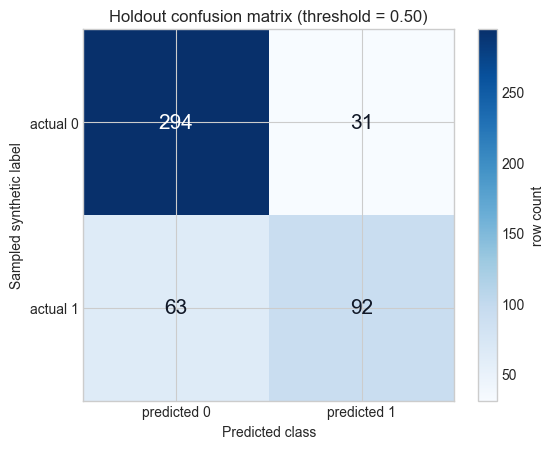

TN=294, FP=31, FN=63, TP=92


In [7]:
predicted = holdout_probabilities >= CLASSIFICATION_THRESHOLD
truth = holdout_y.astype(bool)
tn = int(np.sum(~predicted & ~truth)); fp = int(np.sum(predicted & ~truth))
fn = int(np.sum(~predicted & truth)); tp = int(np.sum(predicted & truth))
confusion = np.array([[tn, fp], [fn, tp]])
fig, ax = plt.subplots(figsize=(5.8, 4.6))
im = ax.imshow(confusion, cmap="Blues")
for row_index in range(2):
    for col_index in range(2):
        value = confusion[row_index, col_index]
        ax.text(col_index, row_index, f"{value}", ha="center", va="center", fontsize=15,
                color="white" if value > confusion.max() * 0.55 else "#111827")
ax.set_xticks([0, 1], labels=["predicted 0", "predicted 1"])
ax.set_yticks([0, 1], labels=["actual 0", "actual 1"])
ax.set_xlabel("Predicted class"); ax.set_ylabel("Sampled synthetic label")
ax.set_title(f"Holdout confusion matrix (threshold = {CLASSIFICATION_THRESHOLD:.2f})")
fig.colorbar(im, ax=ax, label="row count")
fig.tight_layout(); plt.show()
print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}")

## 6. Calibration bins

Calibration asks whether examples assigned similar model probabilities fail at similar synthetic frequencies. Fixed-width bins are descriptive only: this holdout was used for evaluation, not for calibration fitting. Sparse bins should not be overinterpreted, and agreement here cannot establish real-world calibration.

,probability_bin,count,mean_predicted_probability,observed_synthetic_frequency
0,"[0.0, 0.1)",158,0.0393,0.0506
1,"[0.1, 0.2)",77,0.1496,0.2078
2,"[0.2, 0.3)",58,0.2482,0.3103
3,"[0.3, 0.4)",31,0.3435,0.3548
4,"[0.4, 0.5)",33,0.4522,0.3030
5,"[0.5, 0.6)",22,0.5482,0.6818
6,"[0.6, 0.7)",29,0.6443,0.6207
7,"[0.7, 0.8)",30,0.7442,0.8000
8,"[0.8, 0.9)",32,0.8509,0.7812
9,"[0.9, 1.0]",10,0.9418,1.0000


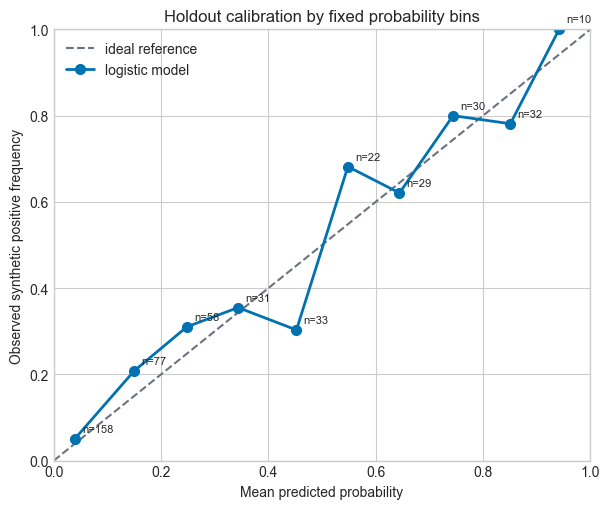

In [8]:
bin_edges = np.linspace(0.0, 1.0, 11)
bin_ids = np.minimum(np.digitize(holdout_probabilities, bin_edges[1:-1], right=False), 9)
calibration_rows = []
for bin_id in range(10):
    mask = bin_ids == bin_id
    count = int(mask.sum())
    calibration_rows.append({
        "probability_bin": f"[{bin_edges[bin_id]:.1f}, {bin_edges[bin_id + 1]:.1f}{']' if bin_id == 9 else ')'}",
        "count": count,
        "mean_predicted_probability": float(holdout_probabilities[mask].mean()) if count else np.nan,
        "observed_synthetic_frequency": float(holdout_y[mask].mean()) if count else np.nan,
    })
calibration = pd.DataFrame(calibration_rows)
display(calibration.round(4))
nonempty = calibration[calibration["count"] > 0]
fig, ax = plt.subplots(figsize=(6.2, 5.2))
ax.plot([0, 1], [0, 1], linestyle="--", color=GRAY, label="ideal reference")
ax.plot(nonempty["mean_predicted_probability"], nonempty["observed_synthetic_frequency"],
        color=BLUE, marker="o", linewidth=2, markersize=7, label="logistic model")
for _, bin_row in nonempty.iterrows():
    ax.annotate(f"n={int(bin_row['count'])}",
                (bin_row["mean_predicted_probability"], bin_row["observed_synthetic_frequency"]),
                xytext=(5, 5), textcoords="offset points", fontsize=8)
ax.set(xlim=(0, 1), ylim=(0, 1), xlabel="Mean predicted probability",
       ylabel="Observed synthetic positive frequency", title="Holdout calibration by fixed probability bins")
ax.legend(frameon=False)
fig.tight_layout(); plt.show()

## 7. OOD detection and abstention examples

The runtime model rejects values outside the artifact's padded training domain and also abstains on missing, nonnumeric, or non-finite required telemetry. An abstention is intentionally a non-prediction: downstream code should not convert it to zero risk.

In [9]:
runtime_model = LogisticRiskModel.load(ARTIFACT_PATH)
normal_example = {name: float(df[name].median()) for name in FEATURE_NAMES}
ood_example = dict(normal_example)
ood_example["bearing_temp_c"] = runtime_model.feature_maxs[FEATURE_NAMES.index("bearing_temp_c")] + 1.0
missing_example = dict(normal_example); del missing_example["vibration_mm_s"]
nonfinite_example = dict(normal_example); nonfinite_example["run_hours"] = float("nan")
examples = {"in-distribution median": normal_example, "OOD bearing temperature": ood_example,
            "missing vibration": missing_example, "non-finite run hours": nonfinite_example}
example_results = []
for name, telemetry in examples.items():
    result = runtime_model.predict(telemetry)
    example_results.append({"example": name, "failure_risk": result.failure_risk,
        "risk_band": result.risk_band, "prediction_status": result.prediction_status,
        "abstained": result.abstained, "out_of_distribution": result.out_of_distribution,
        "reason": result.status_reason})
display(pd.DataFrame(example_results).set_index("example"))

,failure_risk,risk_band,prediction_status,abstained,out_of_distribution,reason
example,,,,,,
in-distribution median,0.188703,low,in_distribution,False,False,None
OOD bearing temperature,NaN,out_of_distribution,out_of_distribution,True,True,Telemetry outside training domain: bearing_temp_c
missing vibration,NaN,abstained,abstained,True,False,Missing or nonnumeric telemetry feature: vibra...
non-finite run hours,NaN,abstained,abstained,True,False,Non-finite telemetry feature: run_hours


## 8. False-negative discussion

At a 0.50 threshold, a false negative is a holdout row whose sampled synthetic label is 1 but whose estimated probability is below 0.50. In a maintenance setting, missed failures could be more costly than extra inspections, so choosing a threshold from accuracy alone would be inappropriate. Lowering the threshold generally raises recall while increasing false positives; a deployment decision would require explicit consequence estimates, capacity constraints, real labeled data, temporal validation, and monitoring. None of those are supplied by this synthetic experiment.

The table below makes the synthetic trade-off visible. It is not a recommendation for an operational threshold.

In [10]:
threshold_rows = []
for threshold in [0.20, 0.30, 0.35, 0.40, 0.50, 0.60, 0.65, 0.70]:
    threshold_predicted = holdout_probabilities >= threshold
    threshold_tp = int(np.sum(threshold_predicted & truth)); threshold_fp = int(np.sum(threshold_predicted & ~truth))
    threshold_fn = int(np.sum(~threshold_predicted & truth)); threshold_tn = int(np.sum(~threshold_predicted & ~truth))
    threshold_rows.append({"threshold": threshold, "false_negative": threshold_fn,
        "false_positive": threshold_fp, "recall": threshold_tp / max(1, threshold_tp + threshold_fn),
        "specificity": threshold_tn / max(1, threshold_tn + threshold_fp)})
threshold_table = pd.DataFrame(threshold_rows)
display(threshold_table.round(4))

,threshold,false_negative,false_positive,recall,specificity
0,0.20,24,114,0.8452,0.6492
1,0.30,42,74,0.7290,0.7723
2,0.35,48,61,0.6903,0.8123
3,0.40,53,54,0.6581,0.8338
4,0.50,63,31,0.5935,0.9046
5,0.60,78,24,0.4968,0.9262
6,0.65,89,18,0.4258,0.9446
7,0.70,96,13,0.3806,0.9600


## 9. Generator circularity and validity threat

The synthetic labels are generated from a logistic function of the same five features later given to a logistic learner. The model is therefore structurally aligned with the generator, and several predictors are themselves derived from shared latent wear, clog, and speed variables. This creates **generator circularity**: good holdout performance mainly shows that the learner recovers a seeded relationship from the simulator, not that it discovers an independent failure mechanism.

Additional limitations include independent row sampling rather than equipment histories, no sensor faults or missingness in training, no site or unit heterogeneity, no maintenance interventions, no concept drift, and no external or temporal validation. OOD guards prevent some unsafe scoring but do not solve unmeasured distribution shift inside the numeric bounds.

## 10. Exact artifact reproduction and checks

The final check calls the existing trainer with its declared seed and defaults, then compares the returned dictionaries directly with the checked-in JSON artifact and metrics. It also compares canonical JSON SHA-256 digests. No model or artifact file is written or modified by this notebook.

In [11]:
reproduced_artifact, reproduced_metrics = fit_model(rows, seed=SEED, iterations=ITERATIONS)
checked_artifact = json.loads(ARTIFACT_PATH.read_text(encoding="utf-8"))
checked_metrics = json.loads(METRICS_PATH.read_text(encoding="utf-8"))

def canonical_digest(value):
    canonical = json.dumps(value, sort_keys=True, separators=(",", ":")).encode("utf-8")
    return hashlib.sha256(canonical).hexdigest()

checks = pd.DataFrame([
    {"check": "model artifact dictionary exact equality", "passed": reproduced_artifact == checked_artifact,
     "reproduced_sha256": canonical_digest(reproduced_artifact), "checked_in_sha256": canonical_digest(checked_artifact)},
    {"check": "metrics dictionary exact equality", "passed": reproduced_metrics == checked_metrics,
     "reproduced_sha256": canonical_digest(reproduced_metrics), "checked_in_sha256": canonical_digest(checked_metrics)},
])
display(checks)
assert checks["passed"].all(), "Checked-in model evidence does not reproduce exactly."
assert reproduced_artifact["training_rows"] == len(train_idx)
assert reproduced_artifact["holdout_rows"] == len(holdout_idx)
assert reproduced_metrics == _metrics(holdout_probabilities, holdout_y)
print("PASS: deterministic generation, split reconstruction, model artifact, and metric summary reproduce exactly.")
print("PASS: runtime model loads the checked-in artifact and exposes explicit OOD/abstention states.")

,check,passed,reproduced_sha256,checked_in_sha256
0,model artifact dictionary exact equality,True,8895fc1eb1f0e9578e32523cc8a1461f7c9e0864ad3ba3...,8895fc1eb1f0e9578e32523cc8a1461f7c9e0864ad3ba3...
1,metrics dictionary exact equality,True,ba460c471f5b65911ac9e3d9a2f253c199c37e8efe392e...,ba460c471f5b65911ac9e3d9a2f253c199c37e8efe392e...


PASS: deterministic generation, split reconstruction, model artifact, and metric summary reproduce exactly.
PASS: runtime model loads the checked-in artifact and exposes explicit OOD/abstention states.


## Conclusion

Within the deterministic synthetic experiment, the logistic model outperforms a majority-class baseline and the checked-in artifact reproduces exactly. The confusion matrix, expanded metrics, and calibration bins characterize this holdout only. False negatives remain material at the default 0.50 classification threshold, and the generator/model structural match limits the evidential strength. Operational use would require real, governed failure labels and validation beyond this synthetic generator.